<a href="https://colab.research.google.com/github/YegorPanin/Konverter/blob/master/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Пример реализации LSTM рекуррентной сети для прогнозирования временных рядов на Keras с использованием датасета солнечных пятен (sunspots)**

##**Прогнозирование временных рядов с помощью рекуррентных нейронных сетей**

*Временно́й ряд* (динамический ряд, ряд динамики) — это последовательность значений некоторых признаков, измеренных через равные промежутки времени.

Во временном ряде для каждого отсчёта должно быть указано время измерения или номер измерения по порядку. Временной ряд существенно отличается от простой выборки данных, так как при анализе учитывается взаимосвязь измерений со временем, а не только статистическое разнообразие и статистические характеристики выборки.

Если каждое измерение содержит значение одного параметра, например, температуры, то рад называется *одномерным*. Если нескольких параметров, то ряд называется *многомерным*.

*Прогнозирование временных рядов* — предсказание будущих значения на основе прошлых и текущих данных. Прогнозирование временного ряда означает, что из последовательности нескольких значений временного ряда (*временного окна*) необходимо предсказать одно или несколько следующих значений ряда. Количество временных шагов, на которые модель предсказывает будущие значения, называется *горизонтом прогнозирования* (Forecasting Horizon).

Для использования рекуррентных нейронных для прогнозирования временных рядов необходимо преобразовать временной ряд в последовательность входов и выходов нейронной сети, в которой каждый вход — это подпоследовательность из *T* предыдущих значений, а выход — следующее значение (или несколько значений в зависимости от значения горизонта прогноза).

Метод преобразования временного ряда в последовательность вход-выход нейронной сети называется *скользящим окном* (Sliding Window). Размер скользящего окна *T* обычно определяется экспериментально и зависит от особенностей прогнозируемого временного ряда. Например, если $T = 5$ , вход — $\left[ {{x_{t - 4}},\;{x_{t - 3}},\;{x_{t - 2}},\;{x_{t - 1}},\;{x_t}} \right]$ , выход — ${x_{t + 1}}$ .

Для рекуррентной нейронной сети формируемая с помощью скользящего окна последовательность вход-выход представляется как трехмерный тензор. 3D-тензор имеет следующую структуру: (samples, time_steps, features):

•	samples (примеры) — количество примеров в данных.
•	time_steps (временные шаги) — размер "скользящего окна".
•	features (признаки) — количество признаков на каждый временной шаг (для одномерного ряда — 1).

Количество примеров (samples) в наборе данных для горизонта прогнозирования, равного единице (прогнозируется одно значение) равно исходному количеству точек временного ряда минус размер скользящего окна (*N*−*T*) из-за специфики формирования последовательностей "вход-выход". Например, для ряда из *N*=7 точек и окна *T*=3: $$X = \left[ {{x_1},\;{x_2},\;{x_3},\;{x_4},\;{x_5},\;{x_6},\;{x_7}} \right]$$

Формируем примеры: $$\begin{array}{*{20}{l}}
{\left[ {{x_1},{x_2},{x_3}} \right] \to {x_4},}\\
{\left[ {{x_2},{x_3},{x_4}} \right] \to {x_5},}\\
{\left[ {{x_3},{x_4},{x_5}} \right] \to {x_6},}\\
{\left[ {{x_4},{x_5},{x_6}} \right] \to {x_7}.}
\end{array}$$

Количество примеров: samples=7−3=4.

Если горизонт прогнозирования не одно значение, а *H* значений (например, прогноз на 3 дня вперед), количество примеров равно: samples=*N−T−H*+1.
Например, для T=3, H=2, N=7 количество примеров равно samples=7−3−2+1=3.

Размер скользящего окна подбирается эмпирически. Для периодических данных рекомендуется брать размер окна равным периоду цикличности данных.



#**Подготовка данных**

Используем датасет Sunspots, содержащий данные о количестве солнечных пятен, наблюдаемых на поверхности Солнца. Эти данные используются для анализа солнечной активности, которая имеет циклический характер с периодом около 11 лет. Основные характеристики датасета:

   Временной охват: Исторические данные доступны с 1749 года по 2013 год (265 лет) в месячном и годовом разрешении.

   Структура данных: Включает дату (в формате год-месяц) и количество солнечных пятен.

   Применение: Прогнозирование солнечных циклов, анализ климатических изменений, исследование влияния солнечной активности на спутники и коммуникационные системы.

   Данные загрузим с официального сайта SILSO - Sunspot Index and Long-term Solar Observations (Индекс солнечных пятен и долгосрочные солнечные наблюдения) Брюселькой обсерватории

   https://www.sidc.be/SILSO/datafiles

  

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Загрузка данных с SILSO (Sunspot Index and Long-term Solar Observations):
#Сайт: https://www.sidc.be/SILSO/datafiles
url = "https://www.sidc.be/SILSO/INFO/snmtotcsv.php"
data = pd.read_csv(url, sep=';', header=None, names=['Year', 'Month', 'Sunspots', 'Std', 'Observations'])
data = data[['Year', 'Month', 'Sunspots']]
values = data['Sunspots'].values.astype('float32')

# Нормализация данных
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(values.reshape(-1, 1))

"""
# Создание оконных данных
#Для создания оконных данных используем функцию append
#X.append(scaled_data[i:(i+look_back), 0])
#Функция создает:
  - срез по времени: i:(i+look_back) — выбирает look_back последовательных
  временных шагов, начиная с индекса i.
  - выбор признака: 0 — указывает на первый столбец данных
  (в данном случае — единственный признак). Этот параметр обязателен!

"""

def create_dataset(data, look_back=1):
    X, Y = [], []
    for i in range(len(data)-look_back-1):
        X.append(scaled_data[i:(i+look_back), 0])  # Окно из look_back значений
        Y.append(scaled_data[i + look_back, 0])    # Следующее значение
    return np.array(X), np.array(Y)

look_back = 30 #Данные одного месяца
X, Y = create_dataset(data, look_back)

# Разделение на train/test
train_size = int(len(X) * 0.8)# 80% от начала ряда
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = Y[:train_size], Y[train_size:]

# Преобразование формы данных в тензор для LSTM [samples, time steps, features]
# Размерность массива X - это не количество значений временного рядя,
# а КОЛИЧЕСТВО ОКОН, равное исходному количеству значений временного ряда минус
# размер скользящего окна
X_train = X_train.reshape(X_train.shape[0], look_back, 1)
X_test = X_test.reshape(X_test.shape[0], look_back, 1)

##**Создание модели**

In [ ]:
model = Sequential()

"""
В ячейке LSTM имеется 4 слоя нейронов одинаковой размерности
(эмпирически подобрана размерность 50).
размерность входа равна скользящему окну look_back,
размерность выхода равна 1
После LSTM расположен 1 нейрон с 50 входами и 1 выходом,
формирующий прогнозируемое значение

"""
model.add(LSTM(50, activation='tanh', input_shape=(look_back, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


##**Обучение с EarlyStopping**

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10) #Если на 10 эпохах не уменьшается loss
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0387 - mae: 0.1685 - val_loss: 0.0144 - val_mae: 0.0988
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0274 - mae: 0.1426 - val_loss: 0.0055 - val_mae: 0.0621
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0157 - mae: 0.1079 - val_loss: 0.0034 - val_mae: 0.0469
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0062 - mae: 0.0662 - val_loss: 0.0017 - val_mae: 0.0324
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0023 - mae: 0.0344 - val_loss: 0.0013 - val_mae: 0.0293
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0020 - mae: 0.0300 - val_loss: 0.0017 - val_mae: 0.0338
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0023 - mae: 0.0322 - val_loss: 0.0013 - val_mae: 0.0297
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0028 - mae: 0.0404 - val_loss: 0.0019 - val_mae: 0.0347
Epoch 9/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.00

##**Прогнозирование**

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
MSE: 2.47
MAE: 1.09
RMSE: 1.57


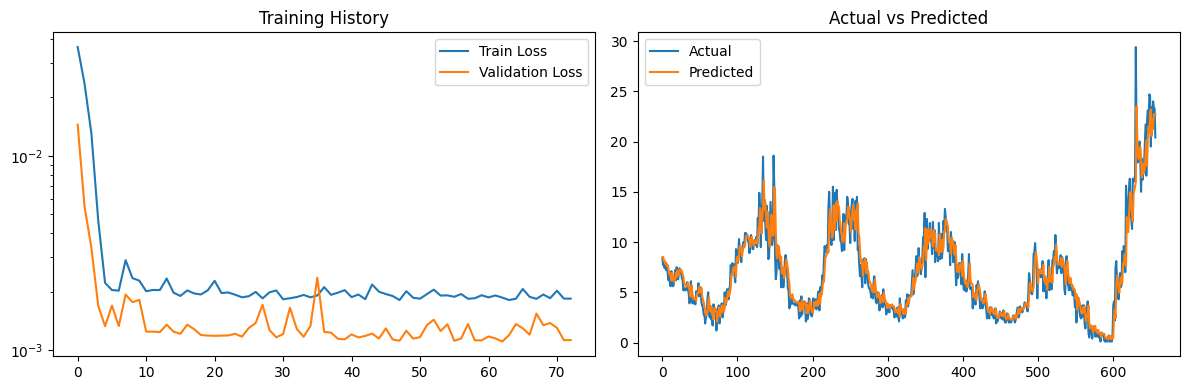

In [ ]:
# Прогнозирование
y_pred = model.predict(X_test)

# Обратное преобразование масштаба
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = scaler.inverse_transform(y_pred)

# Расчет метрик
mse = mean_squared_error(y_test_actual, y_pred_actual)
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)

print(f'MSE: {mse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')

# Графики обучения
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training History')
plt.legend()

# Включение логарифмического масштаба
plt.yscale('log')


# График сравнения прогноза
plt.subplot(1, 2, 2)
plt.plot(y_test_actual, label='Actual')
plt.plot(y_pred_actual, label='Predicted')
plt.title('Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()